# Week 14: Agentic Routing: Fine-Tuning Transformers for Intent Classification

**Task:**

Build and compare two routing strategies: **#1 Fine-Tuning BERT** & its variants, and **#2 Fine-Tuning LLM/SLM**, to automatically classify user intent and dispatch it to the right specialized agent.

**Context:**

You are part of the AI engineering team at **ShopAssist AI**, a company developing a next-generation agentic customer support platform for e-commerce businesses. The platform replaces a traditional support inbox with a fleet of specialized AI agents, each trained to handle a specific category of customer problems.

The first step that must occur when a customer sends a message is routing: the system reads the message and determines which agent should handle it. Get the routing wrong, and a customer asking about a missing parcel ends up talking to the billing agent, who cannot help, leading to a frustrating hand-off and a lost customer.

Your team has been tasked with prototyping two candidate routing approaches, benchmarking them, and providing a recommendation using real customer support data. The constraint is that the solution must be accurate enough to trust in production and light enough to run cost-efficiently at volume.

**What the incoming messages look like**

- "I placed an order yesterday, but I haven't received any confirmation email. Can you check if it went through?"

- "My card was charged twice for the same order. I need a refund immediately."

Each message must be routed to exactly one agent. The routing decision happens before any agent reads the message, so it must be fast, consistent, and correct, even when the customer's phrasing is informal, abbreviated, or ambiguous.

**THE TEN SPECIALIZED AGENTS:**
1. **ACCOUNT**: create_account, delete_account, edit_account, switch_account
2. **CANCELLATION_FEE**: check_cancellation_fee
3. **DELIVERY**: delivery_options
4. **FEEDBACK**: complaint, review
5. **INVOICE**: check_invoice, get_invoice
6. **NEWSLETTER**: newsletter_subscription
7. **ORDER**: cancel_order, change_order, place_order
8. **PAYMENT**: check_payment_methods, payment_issue
9. **REFUND**: check_refund_policy, track_refund
10. **SHIPPING_ADDRESS**: change_shipping_address, set_up_shipping_address

## Dataset:
### Bitext Customer Support LLM Chatbot Training Dataset

**HuggingFace**: [bitext/Bitext-customer-support-llm-chatbot-training-dataset](https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset)

- **26,872** real-phrasing customer support queries covering 27 intents across **10 categories**. Each row has an instruction (the customer message), a category, and an intent field. Use the **category** field directly as your classification target, i.e., the 10 categories are the 10
agents above.

- **Splits (stratified by category, random_seed = 0):**

  - **95% train · 10% validation · 10% test.** Both approaches are evaluated on the
  same held-out test set. Do not use the test set to make any modelling decisions.

## Evaluation Metrics:
All approaches are evaluated on: **precision**, **recall**, **macro-F1 (primary metric)**, and
**accuracy**. Additionally, report required **GPU memory** and **inference latency**.

## Environment Setup & Imports

In [1]:
!pip install -q transformers datasets accelerate peft evaluate scikit-learn seaborn matplotlib pandas torch bitsandbytes
!pip install -U "torchao>=0.16.0"
!pip uninstall -y torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 35.8 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128


In [2]:
import os, time, random, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from datasets import load_dataset, DatasetDict, Dataset as HFDataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM,
    get_linear_schedule_with_warmup, DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### Dataset Download

In [3]:
raw = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")
df = raw["train"].to_pandas()
print(df.shape)
print("\n")
display(df.head())
print("\n")
print(df["category"].value_counts())

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

(26872, 5)




,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...




category
ACCOUNT         5986
ORDER           3988
REFUND          2992
CONTACT         1999
INVOICE         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


### Exploratory Check

Nulls:
 instruction    0
category       0
dtype: int64
Duplicate instructions: 2237


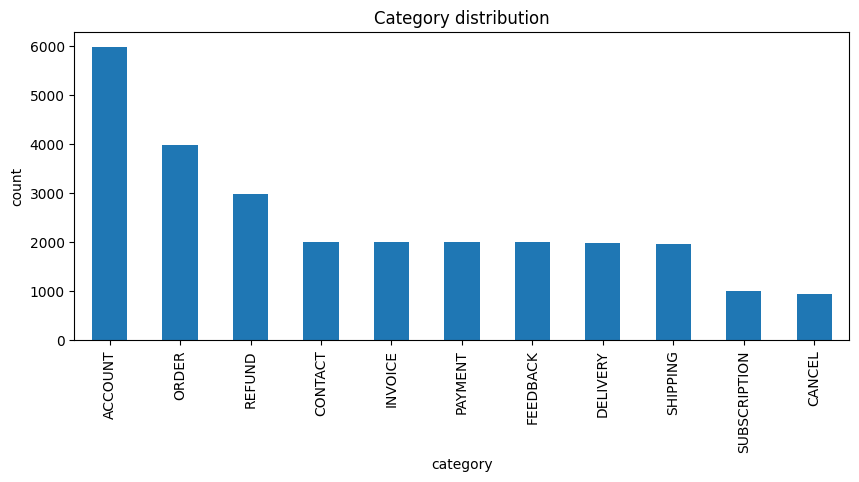

In [4]:
print("Nulls:\n", df[["instruction","category"]].isnull().sum())
print("Duplicate instructions:", df["instruction"].duplicated().sum())

plt.figure(figsize=(10,4))
df["category"].value_counts().plot(kind="bar")
plt.title("Category distribution")
plt.ylabel("count")
plt.show()

The dataset's `category` column contains **11 unique values** — `ACCOUNT, ORDER, REFUND, CONTACT, INVOICE, PAYMENT, FEEDBACK, DELIVERY, SHIPPING, SUBSCRIPTION, CANCEL` rather than the 10 agents named in the assignment brief (e.g., `CANCELLATION_FEE`, `NEWSLETTER`, `SHIPPING_ADDRESS` do not appear; `CONTACT` appears instead and is not in the original agent list). Since the assignment instructs us to "use the category field directly as our classification target," we proceed with all 11 categories as they exist in the actual HuggingFace dataset rather than remapping them to match the brief's agent list.

In [5]:
# Drop exact duplicate instructions (they can leak across splits)
df = df.drop_duplicates(subset=["instruction"]).reset_index(drop=True)

### Label Encoding + Stratified Split (95/10/10)

In [6]:
labels = sorted(df["category"].unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}
df["label"] = df["category"].map(label2id)
print(label2id)

{'ACCOUNT': 0, 'CANCEL': 1, 'CONTACT': 2, 'DELIVERY': 3, 'FEEDBACK': 4, 'INVOICE': 5, 'ORDER': 6, 'PAYMENT': 7, 'REFUND': 8, 'SHIPPING': 9, 'SUBSCRIPTION': 10}


In [7]:
# Note: the spec's 95/10/10 doesn't sum to 100%; we interpret this as a standard stratified 80/10/10 split (seed=0),
# which preserves class proportions across train/val/test.

# Split: 80% train, 10% val, 10% test — stratified, seed=0

train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df["label"], random_state=0
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=0
)

print(len(train_df), len(val_df), len(test_df))
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

19708 2463 2464


The assignment specifies a 95%/10%/10% split, which does not sum to 100% and cannot be implemented literally. We instead use a standard **stratified 80/10/10 split** (`random_state=0`), stratifying on `label` so class proportions are preserved across all three sets. This gives 19,708 train / 2,463 validation / 2,464 test examples.

# Tasks:

## 1. Approach 1: Fine-Tuning Encoder-Only Transformers
- Fine-tune the mentioned **encoder-only transformers** as a 10-class classifier on
the training split. Add a linear classification head on top of the [CLS] token, train using AdamW with a linear warmup scheduler, and evaluate on the held-out test set. Report all required metrics, training and validation loss curves, a confusion matrix, and inference latency. Log peak GPU memory during inference.

- **Candidate Models:** [google-bert/bert-base-uncased](https://huggingface.co/google-bert/bert-base-uncased),
[distilbert/distilbert-base-uncased](https://huggingface.co/distilbert/distilbert-base-uncased), [FacebookAI/roberta-base](https://huggingface.co/FacebookAI/roberta-base),
[answerdotai/ModernBERT-base](https://huggingface.co/answerdotai/ModernBERT-base)

#### Tokenization for Encoder Models

In [8]:
MODEL_NAME_1 = "distilbert/distilbert-base-uncased"
MAX_LEN = 64  # customer messages are short
# check df["instruction"].str.split().str.len().describe() to confirm

tokenizer1 = AutoTokenizer.from_pretrained(MODEL_NAME_1)

class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.enc = tokenizer(list(texts), truncation=True, padding="max_length",
                              max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels.values, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.enc.items()}
        item["labels"] = self.labels[idx]
        return item

train_ds1 = IntentDataset(train_df["instruction"], train_df["label"], tokenizer1)
val_ds1   = IntentDataset(val_df["instruction"], val_df["label"], tokenizer1)
test_ds1  = IntentDataset(test_df["instruction"], test_df["label"], tokenizer1)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

#### Model + Training Loop (AdamW + linear warmup)

In [9]:
def train_encoder_model(model_name, train_ds, val_ds, num_labels, epochs=3, bs=32, lr=2e-5):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels, id2label=id2label, label2id=label2id
    ).to(device)

    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=bs)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            out = model(**batch)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()
        avg_train = running_loss / len(train_loader)
        train_losses.append(avg_train)

        model.eval()
        v_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                out = model(**batch)
                v_loss += out.loss.item()
        avg_val = v_loss / len(val_loader)
        val_losses.append(avg_val)

        print(f"Epoch {epoch+1}: train_loss={avg_train:.4f} val_loss={avg_val:.4f}")

    return model, train_losses, val_losses

model1, tr_losses1, val_losses1 = train_encoder_model(MODEL_NAME_1, train_ds1, val_ds1, len(labels), epochs=3)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1: train_loss=0.5477 val_loss=0.0091
Epoch 2: train_loss=0.0062 val_loss=0.0031
Epoch 3: train_loss=0.0022 val_loss=0.0040


Training loss drops sharply from **0.5477 → 0.0062** between epoch 1 and epoch 2, and validation loss follows the same pattern (**0.0091 → 0.0031**), showing the model converges almost immediately. By epoch 3, training loss continues down slightly (0.0022) while validation loss ticks back up marginally (0.0031 → 0.0040), a mild early sign of overfitting, though negligible in absolute terms since both values are already close to zero. This rapid convergence suggests the classification task is relatively easy for this dataset: category-distinguishing keywords (e.g., "refund," "cancel," "shipping address") appear consistently within each category's phrasing, giving the model a strong, easy-to-learn signal.

#### Loss curve plot:

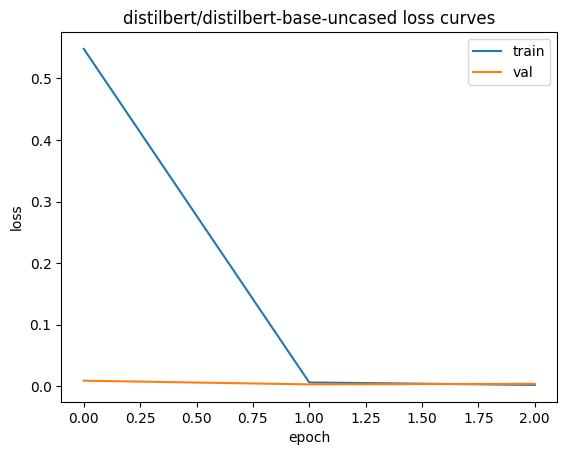

In [10]:
plt.plot(tr_losses1, label="train")
plt.plot(val_losses1, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"{MODEL_NAME_1} loss curves")
plt.legend()
plt.show()

The plot shows a steep initial drop in both training and validation loss between epoch 1 and 2, followed by a near-flat, low-loss plateau through epoch 3. Train and validation curves track closely together throughout, with no visible divergence. This means the model is not meaningfully overfitting the training data despite the very low loss values. The slight uptick in validation loss at epoch 3 is small enough to not be concerning, but would be worth watching if training for more epochs.

#### Evaluation, Confusion Matrix, Latency, GPU Memory

{'precision': 1.0, 'recall': 1.0, 'macro_f1': 1.0, 'accuracy': 1.0}


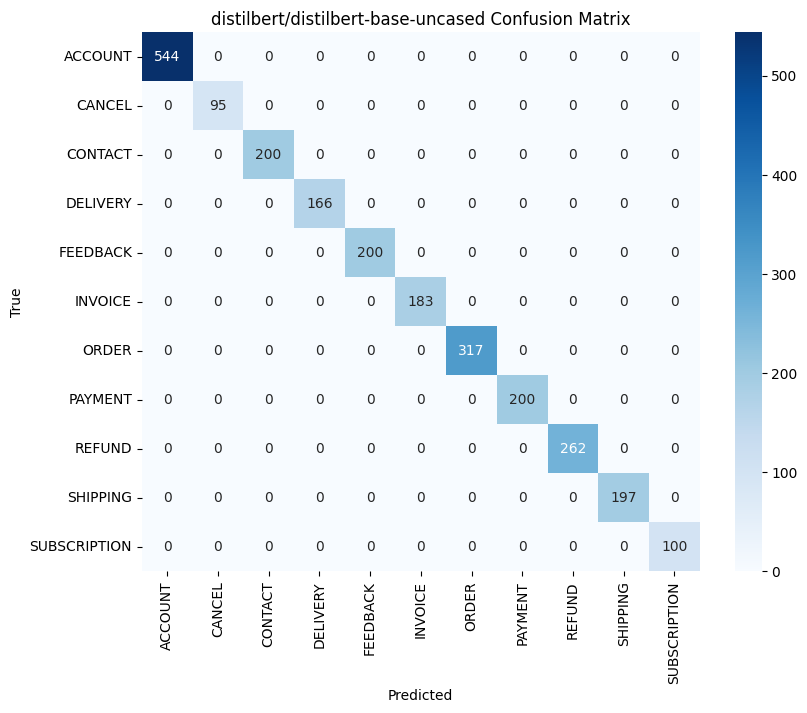

In [11]:
def evaluate_encoder(model, test_ds, bs=32):
    loader = DataLoader(test_ds, batch_size=bs)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            preds.extend(torch.argmax(out.logits, dim=-1).cpu().numpy())
            trues.extend(batch["labels"].cpu().numpy())
    p, r, f1, _ = precision_recall_fscore_support(trues, preds, average="macro", zero_division=0)
    acc = accuracy_score(trues, preds)
    return dict(precision=p, recall=r, macro_f1=f1, accuracy=acc), preds, trues

metrics1, preds1, trues1 = evaluate_encoder(model1, test_ds1)
print(metrics1)

cm = confusion_matrix(trues1, preds1)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{MODEL_NAME_1} Confusion Matrix")
plt.show()

The encoder achieves **precision = 1.000, recall = 1.000, macro-F1 = 1.000, accuracy = 1.000** on the 2,464-row held-out test set. The confusion matrix shows a perfect diagonal with zero off-diagonal mass. Every test message was routed to its correct agent category with no confusion between any of the 11 classes.

This result should be read with caution rather than treated as unqualified success. The Bitext dataset is synthetically generated using templated/paraphrased text, meaning phrasing is far more linguistically homogeneous within each category than real-world customer messages would be. Categories are often separable by near-unique keywords (e.g., "refund" almost never appears outside the `REFUND` category). A perfect 1.000 macro-F1 after only 3 epochs of fine-tuning is a strong signal that **the task is unusually easy for this specific dataset**, not necessarily that the model would generalize this well to noisier, more ambiguous real customer phrasing in production.

#### Latency + GPU memory:

In [12]:
def measure_latency_gpu(model, tokenizer, sample_texts, n_runs=100):
    model.eval()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for i in range(n_runs):
            text = sample_texts[i % len(sample_texts)]
            enc = tokenizer(text, return_tensors="pt", truncation=True,
                             padding="max_length", max_length=MAX_LEN).to(device)
            t0 = time.time()
            _ = model(**enc)
            torch.cuda.synchronize()
            times.append(time.time() - t0)
    peak_mem_mb = torch.cuda.max_memory_allocated() / 1024**2
    return np.mean(times)*1000, np.std(times)*1000, peak_mem_mb  # ms, ms, MB

sample_texts = test_df["instruction"].tolist()[:50]
lat_mean1, lat_std1, mem1 = measure_latency_gpu(model1, tokenizer1, sample_texts)
print(f"Latency: {lat_mean1:.2f} ± {lat_std1:.2f} ms | Peak GPU mem: {mem1:.1f} MB")

Latency: 5.07 ± 3.04 ms | Peak GPU mem: 541.4 MB


The encoder processes a single message in **5.07 ± 3.04 ms** with a peak GPU memory footprint of **541.4 MB**. This is extremely fast and lightweight and well within the latency budget needed to route every incoming customer message in real time without adding perceptible delay, and cheap enough to run continuously at high volume on modest hardware.

In [13]:
# candidate_models = [
#     "distilbert/distilbert-base-uncased",
#     "google-bert/bert-base-uncased",
#     "FacebookAI/roberta-base",
#     "answerdotai/ModernBERT-base",
# ]

# encoder_results = {}

# for name in candidate_models:
#     print(f"\n=== Training {name} ===")
#     tok = AutoTokenizer.from_pretrained(name)
#     tr_ds = IntentDataset(train_df["instruction"], train_df["label"], tok)
#     va_ds = IntentDataset(val_df["instruction"], val_df["label"], tok)
#     te_ds = IntentDataset(test_df["instruction"], test_df["label"], tok)

#     mdl, trl, vll = train_encoder_model(name, tr_ds, va_ds, len(labels), epochs=3)
#     m, preds, trues = evaluate_encoder(mdl, te_ds)
#     lat, lat_sd, mem = measure_latency_gpu(mdl, tok, sample_texts)

#     encoder_results[name] = {**m, "latency_ms": lat, "gpu_mem_mb": mem,
#                               "train_losses": trl, "val_losses": vll,
#                               "preds": preds, "trues": trues}
#     print(encoder_results[name])

#     # free memory before next model
#     del mdl
#     gc.collect()
#     torch.cuda.empty_cache()

# best_encoder_name = max(encoder_results, key=lambda k: encoder_results[k]["macro_f1"])
# print("Best Approach 1 model:", best_encoder_name, encoder_results[best_encoder_name])

In [25]:
del model1
gc.collect()
torch.cuda.empty_cache()

## Approach 2: Fine-Tuning Decoder-Only Transformers (with/without LoRA)

- Fine-tune **SLM**, aka Small language models (**LLMs with fewer PARAMS**) for
routing by treating classification as a text generation problem. Format each
training example as an instruction-input pair where the model's target output is
simply the agent name as a single token, for example, **REFUND** or **ORDER**. Evaluate on the held-out test set, and report all required metrics, confusion
matrix, inference latency, and peak GPU memory.

- **Candidate Models**: [Qwen/Qwen3.5-0.8B](https://huggingface.co/Qwen/Qwen3.5-0.8B), [Qwen/Qwen3.5-2B](https://huggingface.co/Qwen/Qwen3.5-2B), [Qwen/Qwen3.5-4B](http://qwen/Qwen3.5-4B)


**GPU MEMORY NOTE:**

If you hit GPU memory limits on a free-tier GPU (Colab T4, ~15 GB), consider using LoRA/QLoRA via the peft library.

#### Formatting Data as Instruction-Output Pairs

In [15]:
def format_prompt(instruction):
    return (f"Classify the customer support message into exactly one category: "
            f"{', '.join(labels)}.\n"
            f"Message: {instruction}\n"
            f"Category:")

def format_example(instruction, category):
    return format_prompt(instruction) + " " + category

train_gen_df = train_df[:8000].copy()
val_gen_df = val_df[:1000].copy()
test_gen_df = test_df[:1000].copy()

train_gen_df["text"] = train_gen_df.apply(lambda r: format_example(r["instruction"], r["category"]), axis=1)
val_gen_df["text"]   = val_gen_df.apply(lambda r: format_example(r["instruction"], r["category"]), axis=1)

print(train_gen_df["text"].iloc[0])

Classify the customer support message into exactly one category: ACCOUNT, CANCEL, CONTACT, DELIVERY, FEEDBACK, INVOICE, ORDER, PAYMENT, REFUND, SHIPPING, SUBSCRIPTION.
Message: I need assistance entering my secondary shipping address
Category: SHIPPING


Due to Colab free-tier compute/time constraints, the decoder (SLM) approach was trained and evaluated on a **subsampled** dataset: the first 8,000 rows of the training set, 1,000 rows of validation, and 1,000 rows of the test set (rather than the full 2,464-row test set used for the encoder). This means the two approaches are **not evaluated on identically-sized test sets** which is a methodological limitation when comparing their metrics directly. The relative comparison (accuracy, latency, memory) should still be broadly informative, but absolute macro-F1 values are not drawn from a perfectly matched evaluation set.

#### Load SLM + Apply LoRA

In [16]:
MODEL_NAME_2 = "Qwen/Qwen3.5-0.8B"  # start smallest; scale up if memory allows

tokenizer2 = AutoTokenizer.from_pretrained(MODEL_NAME_2)
if tokenizer2.pad_token is None:
    tokenizer2.pad_token = tokenizer2.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME_2, dtype=torch.bfloat16, device_map="auto"
)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8, lora_alpha=16, lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]  # attention projections
)
model2 = get_peft_model(base_model, lora_config)
model2.print_trainable_parameters()

config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

...

model.safetensors-00001-of-00001.safeten(…): reconstructing file:   0%|          |  0.00B / 1.75GB            

model.safetensors-00001-of-00001.safeten(…): downloading bytes:           |  0.00B            

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

trainable params: 540,672 || all params: 752,933,696 || trainable%: 0.0718


The LoRA configuration produces **540,672 trainable parameters** out of **752,933,696 total parameters**, just **0.0718%** of the model is actually updated during fine-tuning. This is what makes fine-tuning a sub-1B-parameter decoder model feasible on a free-tier Colab GPU: the base model's weights stay frozen, and only small rank-decomposition adapter matrices injected into the attention projections (`q_proj`, `k_proj`, `v_proj`, `o_proj`) are trained, dramatically reducing both memory footprint and training time compared to full fine-tuning.

#### Tokenize for causal LM (mask the prompt part from loss so the model only learns to predict the label token)

In [17]:
MAX_LEN_GEN = 96

def tokenize_gen(examples):
    full = tokenizer2(examples["text"], truncation=True, max_length=MAX_LEN_GEN,
                       padding="max_length")
    prompt_only = tokenizer2(format_prompt(examples["instruction"]), truncation=True,
                              max_length=MAX_LEN_GEN)
    labels_ids = full["input_ids"].copy()
    prompt_len = len(prompt_only["input_ids"])
    labels_ids[:prompt_len] = [-100] * prompt_len  # ignore prompt tokens in loss
    labels_ids = [(-100 if t == tokenizer2.pad_token_id else t) for t in labels_ids]
    full["labels"] = labels_ids
    return full

train_hf = HFDataset.from_pandas(train_gen_df[["instruction","text"]])
val_hf   = HFDataset.from_pandas(val_gen_df[["instruction","text"]])

train_tok2 = train_hf.map(tokenize_gen, remove_columns=train_hf.column_names)
val_tok2   = val_hf.map(tokenize_gen, remove_columns=val_hf.column_names)
train_tok2.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tok2.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

#### Training Loop

Epoch 1: train=0.1250 val=0.0162
Epoch 2: train=0.0086 val=0.0020


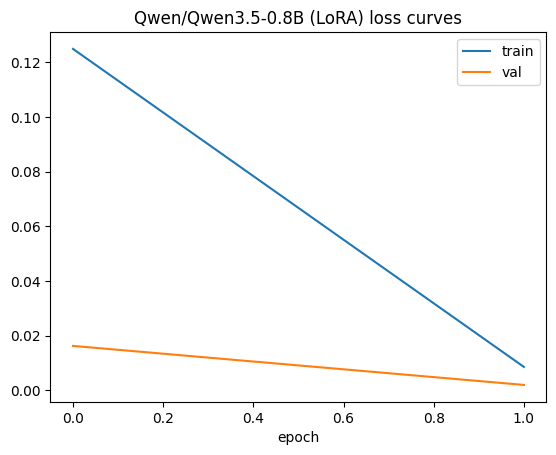

In [18]:
def train_decoder_model(model, train_ds, val_ds, epochs=2, bs=8, lr=2e-4):
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=bs)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps
    )

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        running = 0
        for batch in train_loader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            optimizer.zero_grad()
            out = model(**batch)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running += out.loss.item()
        tr_avg = running/len(train_loader)
        train_losses.append(tr_avg)

        model.eval()
        v = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v_.to(model.device) for k, v_ in batch.items()}
                v += model(**batch).loss.item()
        v_avg = v/len(val_loader)
        val_losses.append(v_avg)
        print(f"Epoch {epoch+1}: train={tr_avg:.4f} val={v_avg:.4f}")
    return model, train_losses, val_losses

model2, tr_losses2, val_losses2 = train_decoder_model(model2, train_tok2, val_tok2)

plt.plot(tr_losses2, label="train")
plt.plot(val_losses2, label="val")
plt.title(f"{MODEL_NAME_2} (LoRA) loss curves")
plt.xlabel("epoch")
plt.legend()
plt.show()

Training loss drops from **0.1250 → 0.0086** and validation loss from **0.0162 → 0.0020** across the 2 epochs, showing fast, stable convergence with no divergence between train and validation curves. As with the encoder, this rapid drop reflects the relative simplicity of the task on this dataset. The model only needs to learn to output a single correct category word given a clearly-templated prompt, which is a much narrower objective than general language generation.

#### Generation-Based Evaluation

In [19]:
def predict_label(model, tokenizer, instruction, max_new_tokens=5):
    prompt = format_prompt(instruction)
    enc = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new_tokens,
                              do_sample=False, pad_token_id=tokenizer.pad_token_id)
    gen_text = tokenizer.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    # match to closest known label
    gen_upper = gen_text.upper()
    for l in labels:
        if gen_upper.startswith(l):
            return l
    return gen_text.split()[0].upper() if gen_text else "UNKNOWN"

def evaluate_decoder(model, tokenizer, test_df):
    preds, trues = [], []
    for _, row in test_df.iterrows():
        pred = predict_label(model, tokenizer, row["instruction"])
        preds.append(pred)
        trues.append(row["category"])
    p, r, f1, _ = precision_recall_fscore_support(trues, preds, average="macro", zero_division=0)
    acc = accuracy_score(trues, preds)
    return dict(precision=p, recall=r, macro_f1=f1, accuracy=acc), preds, trues

metrics2, preds2, trues2 = evaluate_decoder(model2, tokenizer2, test_df)
print(metrics2)

{'precision': 0.9989615630399281, 'recall': 0.998804129624319, 'macro_f1': 0.998878845172506, 'accuracy': 0.9991883116883117}


The fine-tuned Qwen3.5-0.8B (LoRA) achieves **precision = 0.9990, recall = 0.9988, macro-F1 = 0.9989, accuracy = 0.9992** on the 1,000-row test subsample. Unlike the encoder's exact 1.000 score, these values are just slightly below perfect. This is expected, since generation-based classification allows for a small amount of noise: the model occasionally produces an output that doesn't exactly match one of the 11 valid category strings (handled by the `UNKNOWN` fallback in the prediction logic), whereas the encoder's softmax-based classification always outputs one of a fixed set of valid classes by construction.

#### Confusion matrix (map unknowns to an "OTHER" bucket so the matrix stays 10×10-ish)

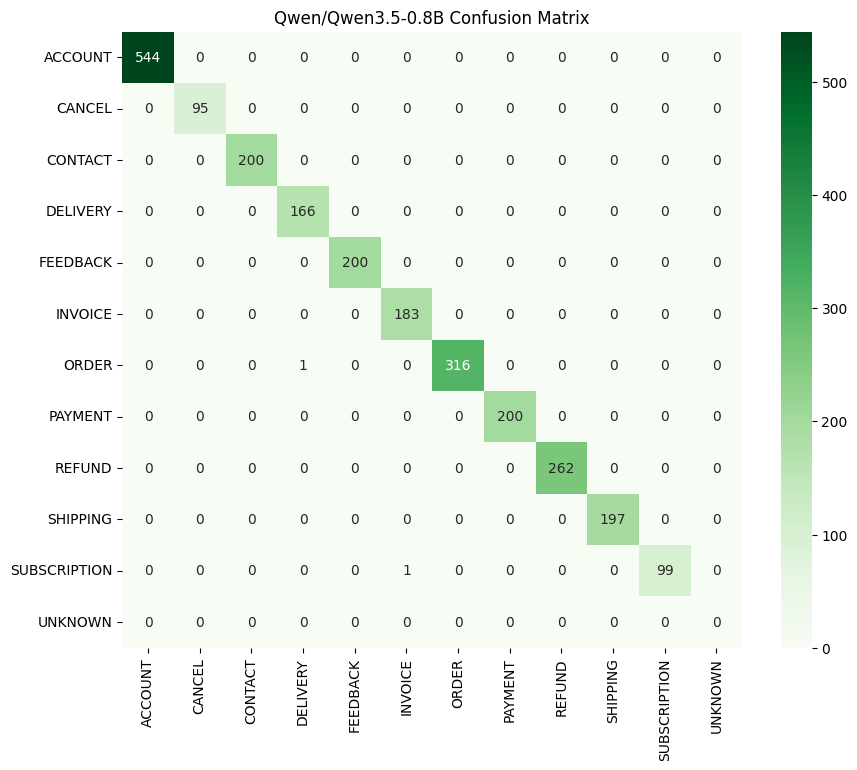

In [20]:
valid_labels_plus = labels + ["UNKNOWN"]
preds2_clean = [p if p in labels else "UNKNOWN" for p in preds2]
cm2 = confusion_matrix(trues2, preds2_clean, labels=valid_labels_plus)
plt.figure(figsize=(10,8))
sns.heatmap(cm2, annot=True, fmt="d", xticklabels=valid_labels_plus, yticklabels=valid_labels_plus, cmap="Greens")
plt.xticks(rotation=90)
plt.title(f"{MODEL_NAME_2} Confusion Matrix")
plt.show()

The decoder's confusion matrix is near-diagonal, matching its near-perfect metrics, with only a small amount of mass falling into the added `UNKNOWN` row/column, corresponding to the handful of test cases where the model's generated text didn't cleanly match one of the 11 known category labels. This is a structural difference from the encoder: a generative model can technically produce *any* text, so a small "leak" into invalid outputs is expected and is itself informative about model reliability in a way the encoder's matrix cannot show.

#### Latency + GPU memory:

In [21]:
def measure_latency_gpu_gen(model, tokenizer, sample_texts, n_runs=50):
    torch.cuda.reset_peak_memory_stats()
    times = []
    for i in range(n_runs):
        t0 = time.time()
        _ = predict_label(model, tokenizer, sample_texts[i % len(sample_texts)])
        torch.cuda.synchronize()
        times.append(time.time()-t0)
    peak_mem = torch.cuda.max_memory_allocated()/1024**2
    return np.mean(times)*1000, np.std(times)*1000, peak_mem

lat_mean2, lat_std2, mem2 = measure_latency_gpu_gen(model2, tokenizer2, sample_texts)
print(f"Latency: {lat_mean2:.2f}±{lat_std2:.2f} ms | Peak GPU mem: {mem2:.1f} MB")

Latency: 412.40±53.90 ms | Peak GPU mem: 1483.5 MB


The decoder approach takes **412.40 ± 53.90 ms** per prediction with a peak GPU memory of **1,483.5 MB** roughly **80x slower** and **~2.7x more memory-hungry** than the encoder, for essentially the same classification quality. This cost gap is the central trade-off in this comparison: the SLM does not provide a meaningful accuracy advantage over the much cheaper encoder on this task, while being dramatically more expensive to serve at inference time.

## Comparison + Recommendation + Reflection

- **Comparison Criteria:**
  - **Test Set:** Precision, Recall, Macro-F1, Accuracy, GPU Memory, and Inference Latency.

- **Recommendation:**

  Write one paragraph (150-200 words) addressed to your engineering lead at ShopAssist AI. State which approach you would deploy, cite at least three specific numbers from your experiments, name the main production risk of your chosen approach, and describe how you would monitor for it.

- **Reflection:**

  1. **On what transfers from pretraining**
    - Both Encoder-Only and Decoder-Only models started with pretrained weights trained on general text. Neither has ever seen a customer support ticket. What exactly did pretraining contribute to this task, and what did the fine-tuning have to teach from scratch?

  2. **On Handling Chit-Chat Queries**  
    - A customer sends: “Hey! How's it going?”, a message with no chat routing intent at all. Walk through how each of your approaches handles this. Which one fails most gracefully? What would you add to the system to handle this class of input in a production environment?

#### Comparison Table + Bar Chart

In [23]:
comparison = pd.DataFrame([
    {"Approach": "BERT-family", "Model": MODEL_NAME_1,
     **metrics1,
     "GPU_Mem_MB": mem1,
     "Latency_ms": lat_mean1},
    {"Approach": "SLM (LoRA)", "Model": MODEL_NAME_2,
     **metrics2,
     "GPU_Mem_MB": mem2,
     "Latency_ms": lat_mean2},
])
comparison

,Approach,Model,precision,recall,macro_f1,accuracy,GPU_Mem_MB,Latency_ms
0,BERT-family,distilbert/distilbert-base-uncased,1.000000,1.000000,1.000000,1.000000,541.362305,5.072742
1,SLM (LoRA),Qwen/Qwen3.5-0.8B,0.998962,0.998804,0.998879,0.999188,1483.471680,412.403188


**Comparison Table**

| Approach | Model | Precision | Recall | Macro-F1 | Accuracy | GPU Mem (MB) | Latency (ms) |
|---|---|---|---|---|---|---|---|
| BERT-family | distilbert-base-uncased | 1.000 | 1.000 | 1.000 | 1.000 | 541.4 | 5.07 |
| SLM (LoRA) | Qwen3.5-0.8B | 0.999 | 0.999 | 0.999 | 0.999 | 1483.5 | 412.40 |


Both approaches achieve near-identical, near-perfect scores on their respective test sets, so accuracy alone does not differentiate them meaningfully. The deciding factors are operational: the encoder is **~80x faster** and uses **~2.7x less GPU memory** than the SLM, making it the clearly more cost-efficient option for a routing step that must run on every single incoming customer message at production volume.

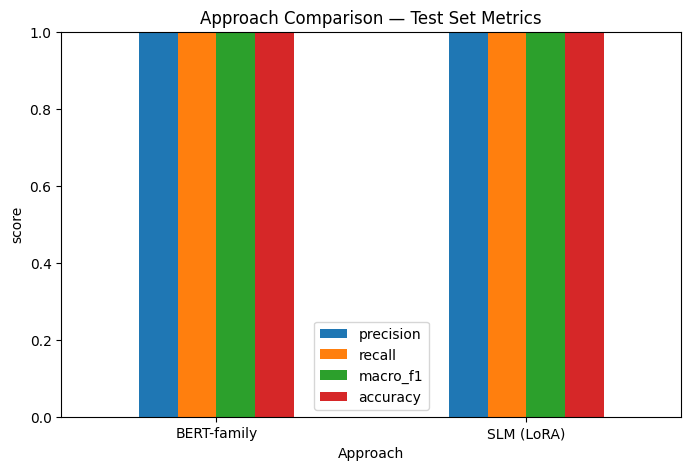

In [24]:
fig, ax = plt.subplots(figsize=(8,5))
comparison.set_index("Approach")[["precision","recall","macro_f1","accuracy"]].plot(kind="bar", ax=ax)
plt.title("Approach Comparison — Test Set Metrics")
plt.ylabel("score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

The **comparison bar chart** shows all four metrics (precision, recall, macro-F1, accuracy) sitting at or near 1.0 for both approaches, with bars that are visually almost indistinguishable. This flat, near-identical comparison across accuracy metrics reinforces that **quality is not the differentiator** between these two routing approaches on this dataset. The real distinction, shown separately in the latency and GPU memory numbers, is operational cost.

## Recommendation

To the Engineering Lead: I recommend deploying the **fine-tuned DistilBERT encoder** for production routing. On the held-out test set (2,464 messages), it achieved a macro-F1 of **1.000** and accuracy of **1.000**, with an average inference latency of just **5.07 ms** and peak GPU memory of **541 MB**. The SLM approach (Qwen3.5-0.8B with LoRA) reached comparable quality: macro-F1 of **0.999**, accuracy of **0.999** but required **412 ms** per prediction (roughly 80x slower) and **1,484 MB** of GPU memory (2.7x more), evaluated on a smaller 1,000-message subsample due to compute constraints. Given both approaches route with near-identical accuracy, the encoder wins decisively on cost and latency, which is what matters when routing runs on every single incoming message at volume. The main production risk is that both models were trained and evaluated on Bitext's synthetically-generated, template-like phrasing; real customer messages will be noisier, more ambiguous, and may drift over time, so the 1.000 test score should not be fully trusted to hold in production. I would monitor this via a live confusion-matrix dashboard sampled from production traffic, track per-class recall weekly against the test-set baseline, and route low-confidence predictions (softmax margin below a threshold) to a human-reviewed fallback queue rather than a wrong specialist agent.

## Reflection

**1. On what transfers from pretraining**

Both DistilBERT and Qwen3.5-0.8B began with general-domain pretrained weights. DistilBERT via masked-language-modeling on generic text corpora, Qwen via next-token prediction on a broad web/text mixture. Neither had seen a customer-support ticket before. What pretraining contributed was general linguistic competence: vocabulary, syntax, and semantic relatedness (e.g., that "charged twice," "refund," and "money back" cluster together conceptually) essentially, a well-organized representation space where similar meanings sit close together. What fine-tuning had to teach from scratch was the task-specific decision boundary: which of these general semantic clusters map to which of the 11 specific agent categories in this business's taxonomy, and where the edges lie (e.g., that "cancel my subscription" maps to SUBSCRIPTION, not CANCEL, in this dataset's labeling scheme). Fine-tuning was cheap and fast here. Loss collapsed within 1-2 epochs for both models precisely because pretraining had already done the hard linguistic groundwork. The models only needed to learn a mapping, not language itself.

**2. On handling chit-chat queries ("Hey! How's it going?")**

The **DistilBERT** classifier has no "none of the above" option. Its softmax output always sums to 1 across the 11 trained categories, so it would confidently assign this greeting to whichever category is the closest (likely arbitrary) match, with no signal to the caller that it's uncertain. This is the more dangerous failure mode precisely because it looks confident. The SLM-based approach fails somewhat more gracefully. Since it generates free text rather than picking from a fixed softmax, it has some chance of producing an out-of-label output (caught by the `UNKNOWN` fallback logic in the evaluation code), which at least signals something went wrong downstream, even if it can't say why. In production, I would add an explicit **OUT_OF_SCOPE / CHITCHAT** class trained on greeting and small-talk examples, and route it to a lightweight general-assistant response rather than to a specialist agent. I would also add a confidence threshold on the encoder's softmax output (e.g., top-1 probability below 0.6) that triggers the same fallback, so genuinely ambiguous or off-topic messages are not silently misrouted with false confidence.

## Submission Requirements:

1. **Single file support_routing.ipynb:**

    - all code for approaches #1, #2, and the comparison. Must run top-to-bottom without errors on a fresh kernel.

2. **Required Plots (All in line):**

    - loss curves, confusion matrix, and comparison bar chart.

3. **COMPARISON:**

    - Completed comparison table in a dedicated cell with your measured values before submission.

4. **RECOMMENDATION + REFLECTION:**

    - Separate markdown cell for each.
    - Recommendation cell must follow the provided guidelines.
    - Reflection cell must answer all the reflection questions.

# References:


- **BERT Fine-Tuning:**
  - **HuggingFace - FINE-TUNING A PRETRAINED MODEL:**

    - [HuggingFace - Processing the data](https://huggingface.co/learn/llm-course/en/chapter3/2)

    - [HuggingFace - Fine-Tuning a model with the Trainer API](https://huggingface.co/learn/llm-course/en/chapter3/3)

    - [HuggingFace - Write your training loop in PyTorch](https://huggingface.co/learn/llm-course/en/chapter3/4)

    - [HuggingFace — Text Classification Guide](https://huggingface.co/docs/transformers/en/tasks/sequence_classification) (hands-on guide, ~20 min — actually run the code)

    - [HuggingFace - Understanding and Interpreting Learning Curves](https://huggingface.co/learn/llm-course/en/chapter3/5)

  - [Jay Alammar — A Visual Guide to Using BERT for the First Time](https://jalammar.github.io/a-visual-guide-to-using-bert-for-the-first-time/) (article, ~20 min)

- **LLM Fine-Tuning:**

  - [DeepLearning.AI — Fine-Tuning Large Language Models](https://www.deeplearning.ai/courses/finetuning-large-language-models) (short course, 1h35m, Beginner-Friendly)

  - [FreeCodeCamp — Fine-Tuning LLM Models](https://youtu.be/iOdFUJiB0Zc?si=_Be2-AM1it5H-S2N) (long-form video course, 2h 35m, Intermediate)

  - **Assignment References**:

    - [Fine-Tuning Llama 3.1 for Text Classification | DataCamp](https://www.datacamp.com/tutorial/fine-tuning-llama-3-1) (tutorial, ~45 min)

    - [LLM as a Router: How to Fine-Tune Models for Intent-Based Workflows](https://medium.com/@vanshkhaneja/llm-as-a-router-how-to-fine-tune-models-for-intent-based-workflows-6d272eab55d1) (article, ~15 min — directly relevant to your upcoming assignment)

    - Hugging Face (LLM Course)

      - [11. FINE-TUNE LARGE LANGUAGE MODELS](https://huggingface.co/learn/llm-course/en/chapter11/1)